In [1]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs
from src.preprocess import (
    qc_report,
    plot_sanity,
    plot_dt_diagnostics,
    bias_from_first_seconds,
    time_range,
    sensor_channel_checks,
    save_qc_outputs,
    build_dataset_qc_table,
    split_qc_pass_fail,
)

In [2]:
# Select one run for detailed QC
RUN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test_2' / 'log_20260223_142511.490'
run = load_run(RUN_DIR, include_pose=False)
acc, gyro, odo = run.acc, run.gyro, run.odo

print('Run:', run.run_id)
for name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    print(f'{name}: n={len(df)}, t_rel=[{df.t_rel.min():.3f}, {df.t_rel.max():.3f}] s')

acc.head(), gyro.head(), odo.head()


Run: log_20260223_142511.490
acc: n=243359, t_rel=[0.000, 2920.408] s
gyro: n=243378, t_rel=[0.000, 2920.637] s
odo: n=365121, t_rel=[0.000, 2921.138] s


(              t      ax      ay      az   t_rel
 0  1.771853e+09  0.0624 -1.0024  0.0056  0.0003
 1  1.771853e+09  0.0562 -1.0027  0.0065  0.0124
 2  1.771853e+09  0.0616 -1.0010  0.0077  0.0245
 3  1.771853e+09  0.0643 -1.0010  0.0101  0.0365
 4  1.771853e+09  0.0598 -0.9995  0.0089  0.0484,
               t      gx      gy      gz   t_rel
 0  1.771853e+09 -3.2827 -9.2139 -1.7769  0.0000
 1  1.771853e+09 -3.5817 -9.3970 -1.6042  0.0112
 2  1.771853e+09 -3.4854 -9.0003 -1.6100  0.0234
 3  1.771853e+09 -3.5680 -9.1529 -1.5374  0.0354
 4  1.771853e+09 -3.6170 -9.0919 -1.7084  0.0473,
               t   v1   v2   t_rel
 0  1.771853e+09 -0.0  0.0  0.0002
 1  1.771853e+09 -0.0  0.0  0.0089
 2  1.771853e+09 -0.0  0.0  0.0168
 3  1.771853e+09 -0.0  0.0  0.0245
 4  1.771853e+09 -0.0  0.0  0.0321)

In [3]:
# Single-run QC report table
single_run_qc = qc_report(run.sensors(), tcol='t_rel').set_index('sensor')
single_run_qc


,n,duration_s,fs_med_hz,dt_med,dt_p99,dt_max,gap_ratio_dtmax_over_dtmed,n_gaps_gt_factor_times_med
sensor,,,,,,,,
acc,243359,2920.4082,83.332751,0.0120,0.0130,0.0279,2.324982,0
gyro,243378,2920.6368,83.332751,0.0120,0.0130,0.0280,2.333327,0
odo,365121,2921.1373,129.870696,0.0077,0.0088,0.0248,3.220801,0


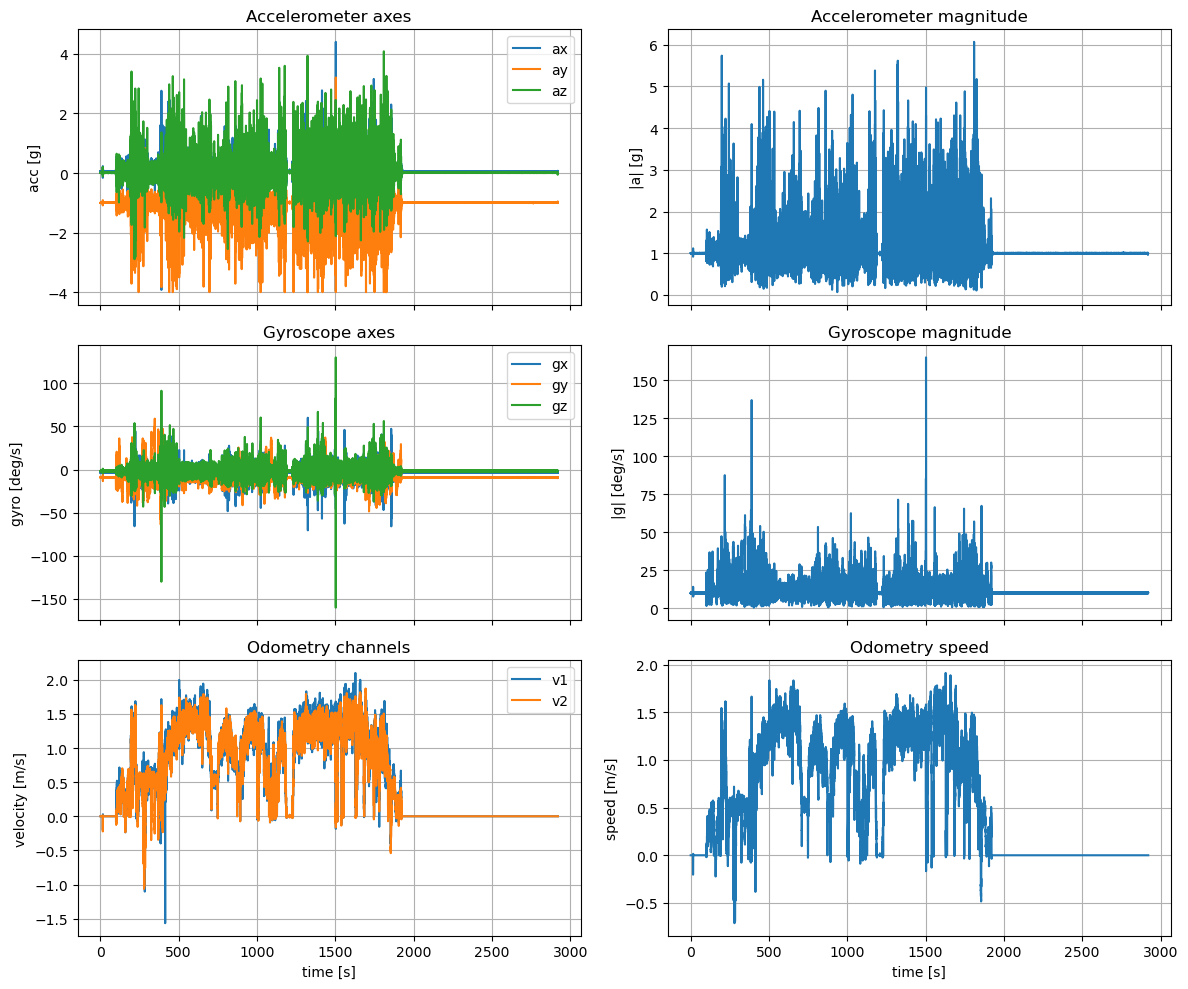

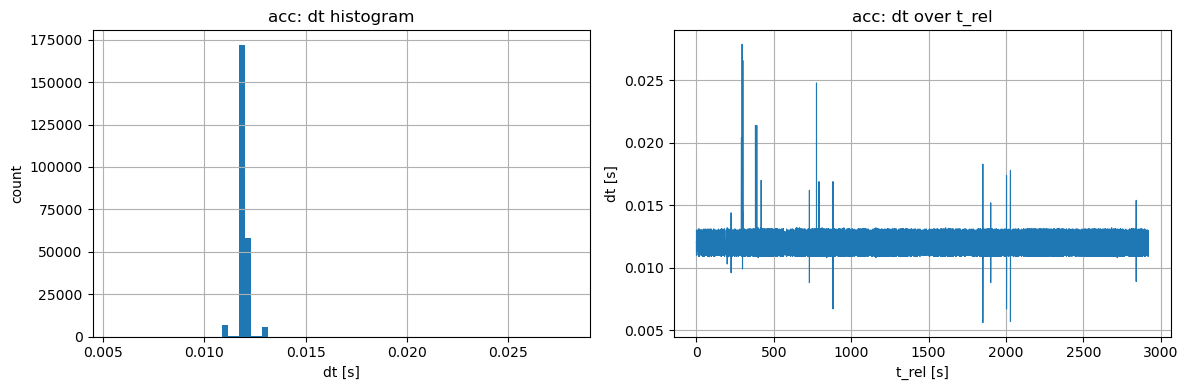

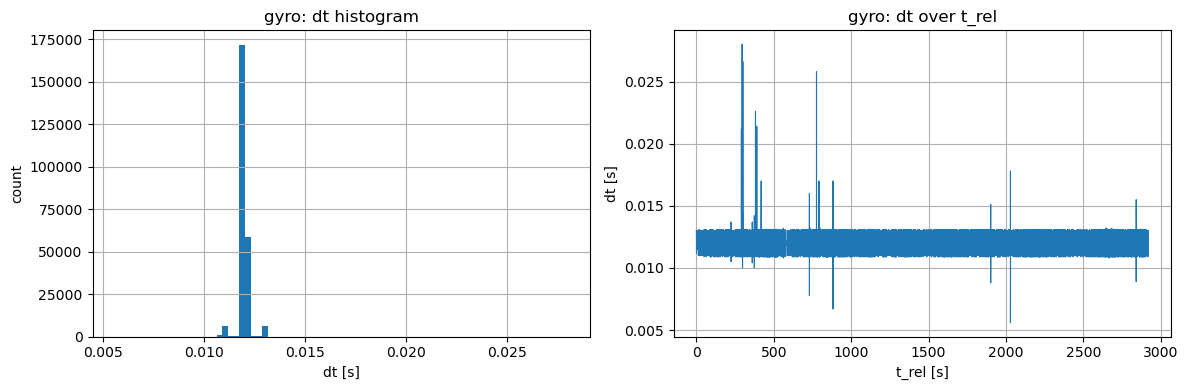

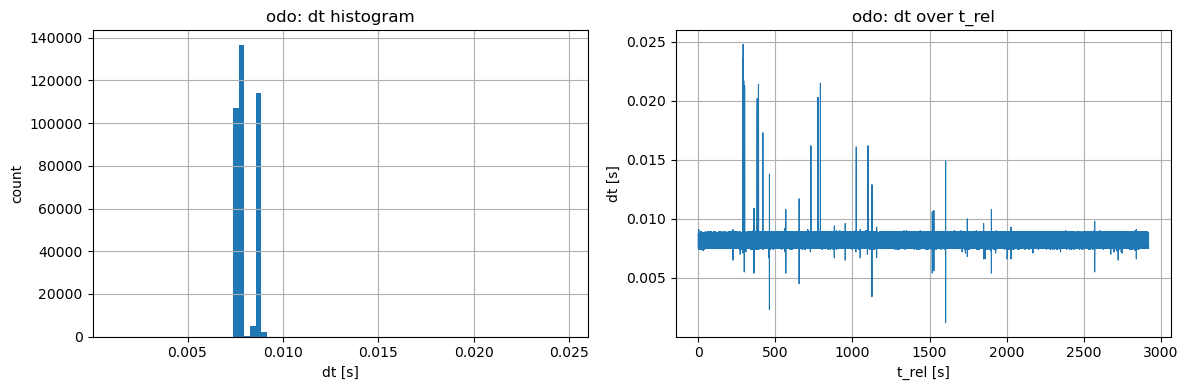

In [4]:
# Single-run sanity plots + dt diagnostics
plot_sanity(acc, gyro, odo, tcol='t_rel', show=True)
for sensor_name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    fig = plot_dt_diagnostics(sensor_name, df, tcol='t_rel', bins=80, show=True)
    if fig is None:
        print(f'{sensor_name}: not enough samples for dt diagnostics')


In [5]:
# Bias/time-range and sensor saturation checks
gyro_bias = bias_from_first_seconds(gyro, ['gx', 'gy', 'gz'], tcol='t_rel', seconds=5)
acc_bias = bias_from_first_seconds(acc, ['ax', 'ay', 'az'], tcol='t_rel', seconds=5)
acc_mag_median_5s = ((acc['ax']**2 + acc['ay']**2 + acc['az']**2) ** 0.5)[acc['t_rel'] <= 5].median()

print('Gyro bias (first 5s):')
print(gyro_bias)
print('\nAcc mean (first 5s):')
print(acc_bias)
print('\nAcc |a| median (first 5s):', float(acc_mag_median_5s) if pd.notna(acc_mag_median_5s) else float('nan'))

ranges = pd.DataFrame(
    {
        'sensor': ['acc', 'gyro', 'odo'],
        't_min': [time_range(acc)[0], time_range(gyro)[0], time_range(odo)[0]],
        't_max': [time_range(acc)[1], time_range(gyro)[1], time_range(odo)[1]],
    }
).set_index('sensor')
print('\nTime ranges (t_rel):')
ranges

range_sat_checks = pd.concat(
    [
        sensor_channel_checks(acc, ['ax', 'ay', 'az'], 'acc'),
        sensor_channel_checks(gyro, ['gx', 'gy', 'gz'], 'gyro'),
    ],
    ignore_index=True,
)
print('\nRange/saturation checks:')
range_sat_checks


Gyro bias (first 5s):
gx   -3.522300
gy   -9.131085
gz   -1.634819
dtype: float64

Acc mean (first 5s):
ax    0.060389
ay   -0.999964
az    0.008413
dtype: float64

Acc |a| median (first 5s): 1.0018577244299713

Time ranges (t_rel):

Range/saturation checks:


,sensor,channel,max_abs,n,n_unique,repeat_ratio,longest_constant_run,clip_candidate_count,flag_frozen,flag_flat_top
0,acc,ax,4.4039,243359,14524,0.005305,4,1,False,False
1,acc,ay,3.9999,243359,8005,0.014012,4,21,False,False
2,acc,az,4.0865,243359,15818,0.003645,4,1,False,False
3,gyro,gx,70.4852,243378,87711,0.002358,3,1,False,False
4,gyro,gy,63.9014,243378,3003,0.032337,5,2,False,False
5,gyro,gz,160.2162,243378,88695,0.002354,3,1,False,False


In [6]:
# Save QC artifacts per run (mirrors data/raw labels under reports/raw)
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
ARTIFACT_ROOT = PROJECT_ROOT / 'reports' / 'raw'
runs_for_artifacts = load_runs(RAW_ROOT, include_pose=False)
save_qc_outputs(runs_for_artifacts, raw_root=RAW_ROOT, out_root=ARTIFACT_ROOT, tcol='t_rel')
print(f'Saved QC artifacts for {len(runs_for_artifacts)} runs to: {ARTIFACT_ROOT}')


Saved QC artifacts for 7 runs to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/raw


In [7]:
# Multi-run QC dashboard + pass/fail filtering
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
runs = load_runs(RAW_ROOT, include_pose=False)


"""A run is good if pass_all == True. pass_all is true only if all are true:
- pass_dt_gaps: no large timestamp gaps in any sensor (n_gaps_gt_factor_times_med == 0), where large gap means dt > 5 * median_dt
- pass_duration: each sensor duration is at least min_duration_s (here we use 30s)
- pass_fs: median sample rate in expected range:
    - acc: 70-100 Hz
    - gyro: 70-100 Hz
    - odo: 100-150 Hz
"""
dataset_qc = build_dataset_qc_table(runs, tcol='t_rel', min_duration_s=30.0)
dataset_qc_good, dataset_qc_bad, good_run_ids, bad_run_ids = split_qc_pass_fail(dataset_qc)

print('Good runs:', len(good_run_ids))
print(good_run_ids)
print('Bad runs:', len(bad_run_ids))
print(bad_run_ids)

dataset_qc


Good runs: 5
['log_20251222_120952.855', 'log_20260209_125910.654', 'log_20260216_114652.530', 'log_20260223_142511.490', 'log_20260226_102148.990']
Bad runs: 2
['log_20251219_134611.366', 'log_20251222_115149.656']


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,...,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,
log_20251219_134611.366,5.0,0.0483,82.987327,0.01205,0.012197,0.0122,1.012435,0.0,5.0,0.0485,...,128.203448,0.0078,0.0087,0.0087,1.115356,0.0,True,False,True,False
log_20251222_115149.656,24801.0,297.6012,83.334406,0.01200,0.013000,0.5222,43.517236,1.0,24801.0,297.6003,...,129.870696,0.0077,0.0088,0.5179,67.260032,1.0,False,True,True,False
log_20251222_120952.855,12437.0,149.2332,83.332751,0.01200,0.013000,0.0131,1.091671,0.0,12437.0,149.2343,...,129.870696,0.0077,0.0088,0.0097,1.259754,0.0,True,True,True,True
log_20260209_125910.654,29643.0,355.7067,83.332751,0.01200,0.013000,0.0172,1.433323,0.0,29986.0,359.8211,...,129.870696,0.0077,0.0088,0.0138,1.792234,0.0,True,True,True,True
log_20260216_114652.530,145708.0,1748.8328,83.332751,0.01200,0.013000,0.0287,2.391659,0.0,147427.0,1769.4578,...,129.870696,0.0077,0.0088,0.0248,3.220801,0.0,True,True,True,True
log_20260223_142511.490,243359.0,2920.4082,83.332751,0.01200,0.013000,0.0279,2.324982,0.0,243378.0,2920.6368,...,129.870696,0.0077,0.0088,0.0248,3.220801,0.0,True,True,True,True
log_20260226_102148.990,181067.0,2172.7994,83.332751,0.01200,0.013000,0.0177,1.474986,0.0,182779.0,2193.3403,...,129.870696,0.0077,0.0088,0.0164,2.129861,0.0,True,True,True,True
